In [35]:
import numpy as np

a = 1.4
b = 0.3

N = 100000
transient = 1000

x, y = 0.0, 0.0

Q = np.eye(2)
lyap_sum = np.zeros(2)

for n in range(N):
    J = np.array([[-2*a*x, 1],
                  [b,      0]])

    Z = J @ Q
    Q, R = np.linalg.qr(Z)

    if n >= transient:
        lyap_sum += np.log(np.abs(np.diag(R)))

    x, y = 1 - a*x**2 + y, b*x

lyap = lyap_sum / (N - transient)
print(lyap)

[ 0.41984733 -1.62382014]


In [36]:
import numpy as np
import matplotlib.pyplot as plt

In [37]:
x = np.linspace(-2, 2, 100)
y_top = 0.25 * np.ones_like(x)
y_bottom = -0.25 * np.ones_like(x)

y = np.linspace(-0.25, 0.25, 100)
x_left = -2 * np.ones_like(y)
x_right = 2 * np.ones_like(y)

In [38]:
def Fold_Map(x, y):
    x1 = 0.3*x
    y1 = 1 - 0.35 * x**2 + y

    return x1, y1

In [39]:
x1_top, y1_top = Fold_Map(x, y_top)
x1_bottom, y1_bottom = Fold_Map(x, y_bottom)

x1_left, y1_left = Fold_Map(x_left, y)
x1_right, y1_right = Fold_Map(x_right, y)

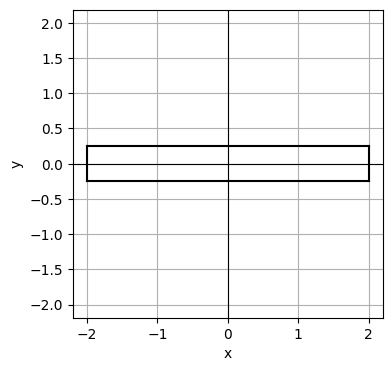

In [40]:
plt.figure(figsize=(4, 4))

plt.plot(x, y_top, 'k')
plt.plot(x, y_bottom, 'k')
plt.plot(x_left, y, 'k')
plt.plot(x_right, y, 'k')

plt.axhline(0, color='k', linewidth=0.8)
plt.axvline(0, color='k', linewidth=0.8)

plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.grid(True)
plt.savefig("square.png", dpi=300, bbox_inches="tight")
plt.show()

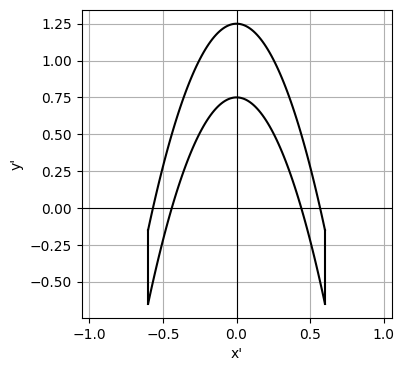

In [41]:
plt.figure(figsize=(4, 4))

plt.plot(x1_top, y1_top, 'k')
plt.plot(x1_bottom, y1_bottom, 'k')
plt.plot(x1_left, y1_left, 'k')
plt.plot(x1_right, y1_right, 'k')

plt.axhline(0, color='k', linewidth=0.8)
plt.axvline(0, color='k', linewidth=0.8)

plt.xlabel("x'")
plt.ylabel("y'")
plt.axis("equal")
plt.grid(True)
plt.savefig("square_Fold.png", dpi=300, bbox_inches="tight")
plt.show()

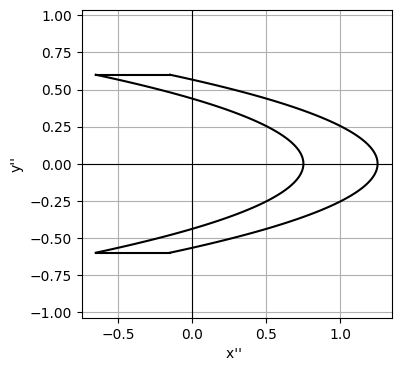

In [42]:
plt.figure(figsize=(4, 4))

plt.plot(y1_top, x1_top, 'k')
plt.plot(y1_bottom, x1_bottom, 'k')
plt.plot(y1_left, x1_left, 'k')
plt.plot(y1_right, x1_right, 'k')

plt.axhline(0, color='k', linewidth=0.8)
plt.axvline(0, color='k', linewidth=0.8)

plt.xlabel(f"x'' ")
plt.ylabel("y''")
plt.axis("equal")
plt.grid(True)
plt.savefig("square_axis.png", dpi=300, bbox_inches="tight")
plt.show()